# Spatial clustering with BINARY + pymclustR

BINARY uses a binary presence/absence representation — strong on very large or very sparse spatial data.

This notebook runs the BINARY spatial embedder on the
**Maynard 151676 dorsolateral prefrontal cortex** Visium sample
(3 460 spots × 10 747 genes) and clusters the resulting embedding with
[`pymclustR`](https://pypi.org/project/pymclustR/), a pure-Python
re-implementation of CRAN `mclust` (no `rpy2` / R dependency).

> Pre-processed input lives at
> `/scratch/users/steorra/analysis/omicverse_dev/omicverse-test/notebooks/data/cluster_svg.h5ad`,
> which is the canonical fixture used in the original `t_cluster_space`
> tutorial.


## 0. Load AnnData + Ground Truth

In [1]:
import omicverse as ov
import scanpy as sc
import pandas as pd, os, anndata as ad

ov.style(font_path='Arial')

# Load the pre-processed AnnData (3460 spots × 10747 genes — the same
# input the original spatial-clustering tutorial was developed against).
DATA_DIR = '/scratch/users/steorra/analysis/omicverse_dev/omicverse-test/data/151676'
H5AD     = '/scratch/users/steorra/analysis/omicverse_dev/omicverse-test/notebooks/data/cluster_svg.h5ad'
adata = ad.read_h5ad(H5AD)
truth = pd.read_csv(os.path.join(DATA_DIR, '151676_truth.txt'),
                    sep='\t', header=None, index_col=0)
truth.columns = ['Ground Truth']
adata.obs['Ground Truth'] = truth['Ground Truth'].reindex(adata.obs_names)
print('shape:', adata.shape, '  annotated:',
      adata.obs['Ground Truth'].notna().sum())
adata


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
Using already downloaded Arial font from: /tmp/omicverse_arial.ttf
Registered as: Arial
🧬 Detecting GPU devices…


✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.2rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



shape: (3460, 10747)   annotated: 3431


AnnData object with n_obs × n_vars = 3460 × 10747
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'space_variable_features', 'highly_variable'
    uns: 'REFERENCE_MANU', 'spatial'
    obsm: 'spatial'
    layers: 'counts'

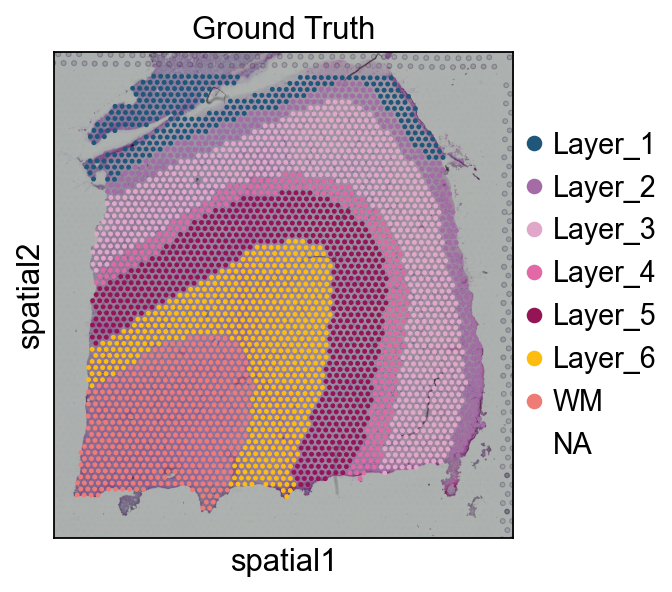

In [2]:
sc.pl.spatial(adata, img_key='hires', color=['Ground Truth'])

## 1. Embed with BINARY

BINARY (Lin et al., *Cell Genomics* 2024) shows that complete spatial
gene expression isn't necessary for identifying spatial domains — a
binary-presence representation is enough. Strong choice for very large
or very sparse spatial data.


In [3]:
methods_kwargs = {'BINARY': {
    'use_method': 'KNN', 'cutoff': 6, 'obs_key': 'BINARY_sample',
    'use_list': None, 'pos_weight': 10, 'device': 'cuda:0',
    'hidden_dims': [512, 30], 'n_epochs': 1000, 'lr': 0.001,
    'key_added': 'BINARY', 'gradient_clipping': 5,
    'weight_decay': 0.0001, 'verbose': True, 'random_seed': 0,
    'lognorm': 1e4, 'n_top_genes': 2000,
}}
adata = ov.space.clusters(adata, methods=['BINARY'],
                          methods_kwargs=methods_kwargs)


The BINARY method is used to embed the spatial data.
Recover the counts matrix from log-normalized data.


  0%|                                                                                                            | 0/3460 [00:00<?, ?it/s]

  5%|████▊                                                                                           | 175/3460 [00:00<00:01, 1748.83it/s]

 10%|█████████▋                                                                                      | 351/3460 [00:00<00:01, 1752.96it/s]

 15%|██████████████▌                                                                                 | 527/3460 [00:00<00:01, 1754.14it/s]

...

 93%|██████████████████████████████████████████████████████████████████████████████████████████       | 929/1000 [00:03<00:00, 308.62it/s]

 96%|█████████████████████████████████████████████████████████████████████████████████████████████    | 960/1000 [00:03<00:00, 308.70it/s]

 99%|████████████████████████████████████████████████████████████████████████████████████████████████▏| 991/1000 [00:03<00:00, 308.57it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:03<00:00, 280.30it/s]

The binary embedding are stored in adata.obsm["BINARY"]. 
Shape: (3460, 30)


## 2. Cluster with pymclustR (no rpy2 / R needed)


finished: found 10 clusters and added
    'pymclustR', the cluster labels (adata.obs, categorical)
    [model=EEE, loglik=-161362.2793, BIC=-329031.9030]


  0%|                                                                                                            | 0/3460 [00:00<?, ?it/s]

 37%|███████████████████████████████████▏                                                          | 1297/3460 [00:00<00:00, 12969.55it/s]

 75%|██████████████████████████████████████████████████████████████████████▍                       | 2594/3460 [00:00<00:00, 12913.70it/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████| 3460/3460 [00:00<00:00, 12892.43it/s]

The merged cluster information is stored in adata.obs["pymclustR_BINARY_tree"].


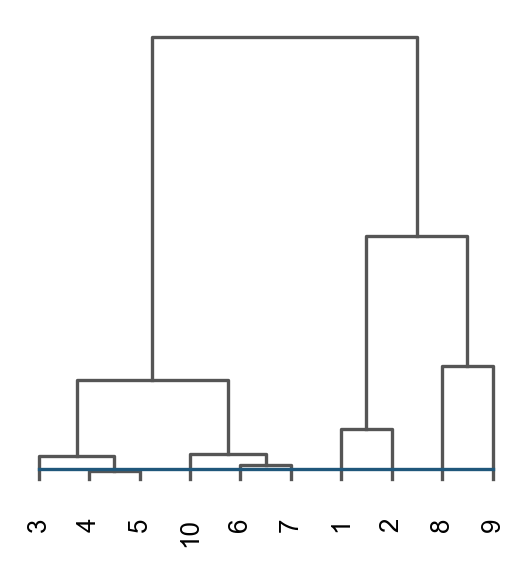

In [4]:
ov.utils.cluster(adata, use_rep='BINARY', method='pymclustR',
                 n_components=10, modelNames='EEE', random_state=42)
adata.obs['pymclustR_BINARY'] = ov.utils.refine_label(adata, radius=30, key='pymclustR')
adata.obs['pymclustR_BINARY'] = adata.obs['pymclustR_BINARY'].astype('category')
res = ov.space.merge_cluster(adata, groupby='pymclustR_BINARY',
                             use_rep='BINARY',
                             threshold=0.01, plot=True)


## 3. Spatial visualisation

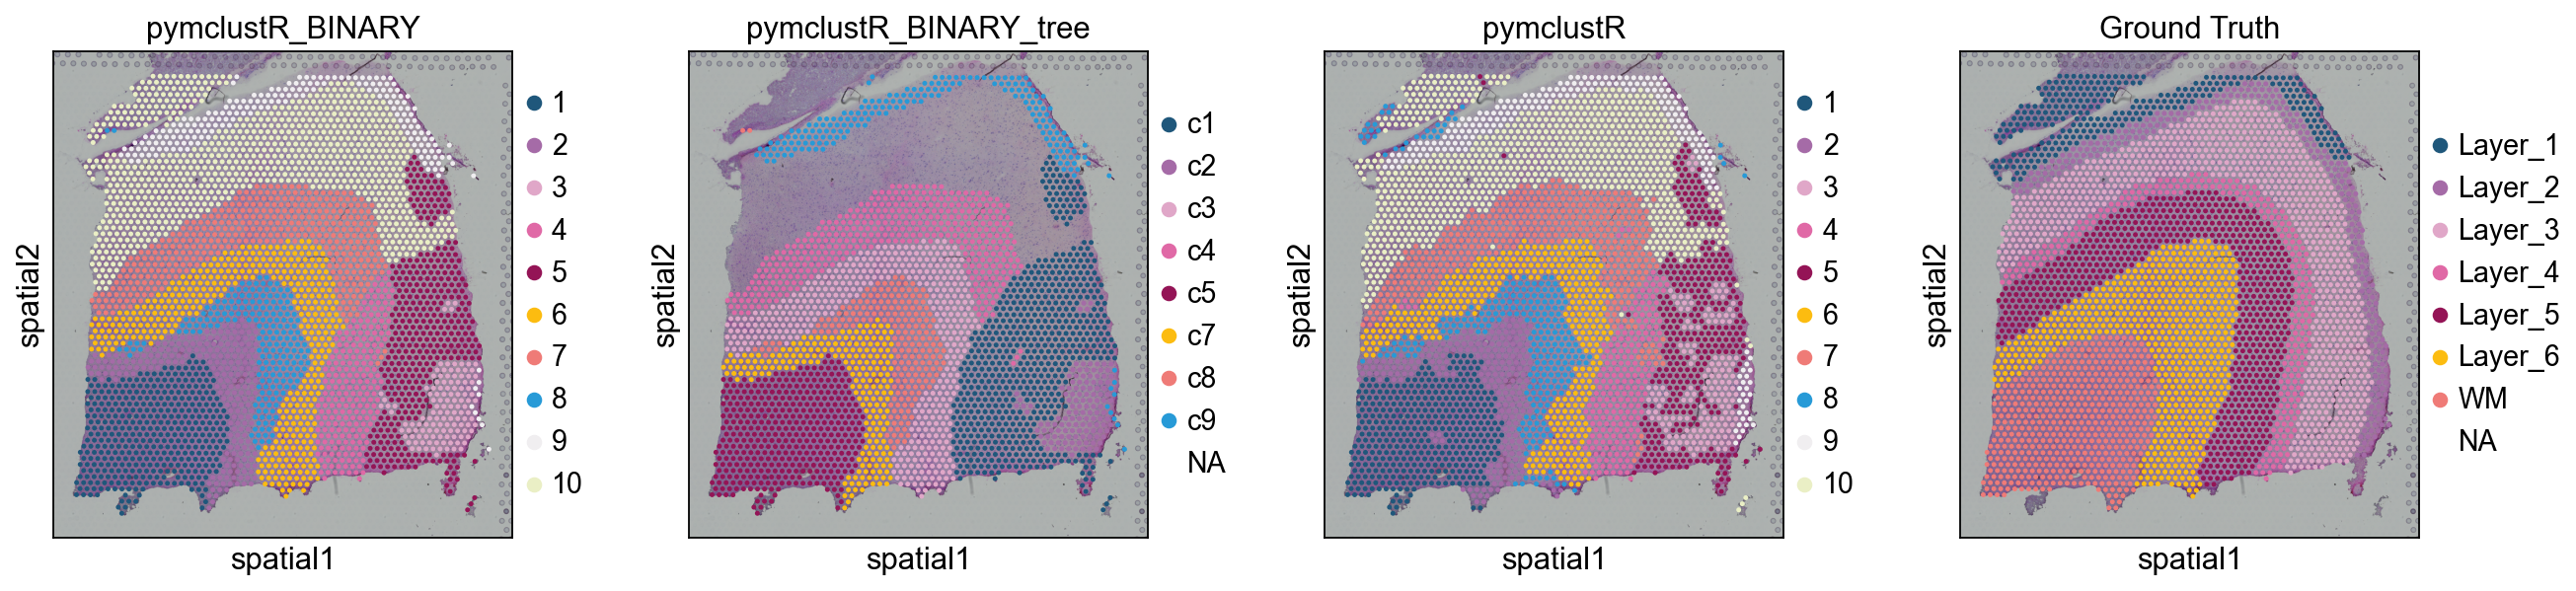

In [5]:
sc.pl.spatial(adata, color=['pymclustR_BINARY',
                            'pymclustR_BINARY_tree' if 'pymclustR_BINARY_tree' in adata.obs.columns else 'pymclustR_BINARY',
                            'pymclustR', 'Ground Truth'])


## 4. ARI vs Maynard ground truth

In [6]:
from sklearn.metrics.cluster import adjusted_rand_score

obs = adata.obs.dropna(subset=['Ground Truth'])
ari_raw = adjusted_rand_score(obs['pymclustR'], obs['Ground Truth'])
ari_ref = adjusted_rand_score(obs['pymclustR_BINARY'], obs['Ground Truth'])
print(f'BINARY + pymclustR (raw):     ARI = {ari_raw:.4f}')
print(f'BINARY + pymclustR (refined): ARI = {ari_ref:.4f}')


BINARY + pymclustR (raw):     ARI = 0.4086
BINARY + pymclustR (refined): ARI = 0.4163
